<a href="https://colab.research.google.com/github/mirandapachini/Advanced-Analytical-Tools/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required libraries
!pip -q install scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as snsº
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


Question 1

In [ ]:
# Query and Documents

q_text= "python manager"
d1_text= "python engineer analyst"
d2_text= "product manager python"
d3_text= "python analyst engineer"

documents=[d1_text, d2_text, d3_text]
documents_names=["d1", "d2", "d3"]
docs=dict(zip(documents_names, documents))

query=q_text

In [ ]:
# Create a simple word count vectorizer
count_vectorizer = CountVectorizer(stop_words='english', max_features=15)
count_matrix = count_vectorizer.fit_transform(documents)

# Convert to DataFrame for better visualization
count_df = pd.DataFrame(
    count_matrix.toarray(),
    columns=count_vectorizer.get_feature_names_out(),
    index=documents_names
)

print("Word Count Matrix:")
print(count_df)


Word Count Matrix:
    analyst  engineer  manager  product  python
d1        1         1        0        0       1
d2        0         0        1        1       1
d3        1         1        0        0       1


In [ ]:
# Create TF-IDF vectorizer (log transform not raw IDF)
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=15)
tfidf_matrix = tfidf_vectorizer.fit_transform(documents)

# Convert to DataFrame
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out(),
    index=documents_names
)

print("TF-IDF Matrix:")
print(tfidf_df.round(3))
print("\n Notice: Words that appear in fewer documents get higher scores!")

TF-IDF Matrix:
    analyst  engineer  manager  product  python
d1     0.62      0.62    0.000    0.000   0.481
d2     0.00      0.00    0.652    0.652   0.385
d3     0.62      0.62    0.000    0.000   0.481

 Notice: Words that appear in fewer documents get higher scores!


In [ ]:
print("Top 3 Most Important Words in Each Review:\n")

for documents_idx, documents_names in enumerate(documents):
    # Get TF-IDF scores for this review
    scores = tfidf_df.iloc[documents_idx]
    # Sort and get top 3
    top_words = scores.nlargest(3)

    print(f"{documents_names}:")
    for word, score in top_words.items():
        print(f"  • {word}: {score:.3f}")
    print(f"  Original: {documents[documents_idx][:60]}...\n")

Top 3 Most Important Words in Each Review:

python engineer analyst:
  • analyst: 0.620
  • engineer: 0.620
  • python: 0.481
  Original: python engineer analyst...

product manager python:
  • manager: 0.652
  • product: 0.652
  • python: 0.385
  Original: product manager python...

python analyst engineer:
  • analyst: 0.620
  • engineer: 0.620
  • python: 0.481
  Original: python analyst engineer...



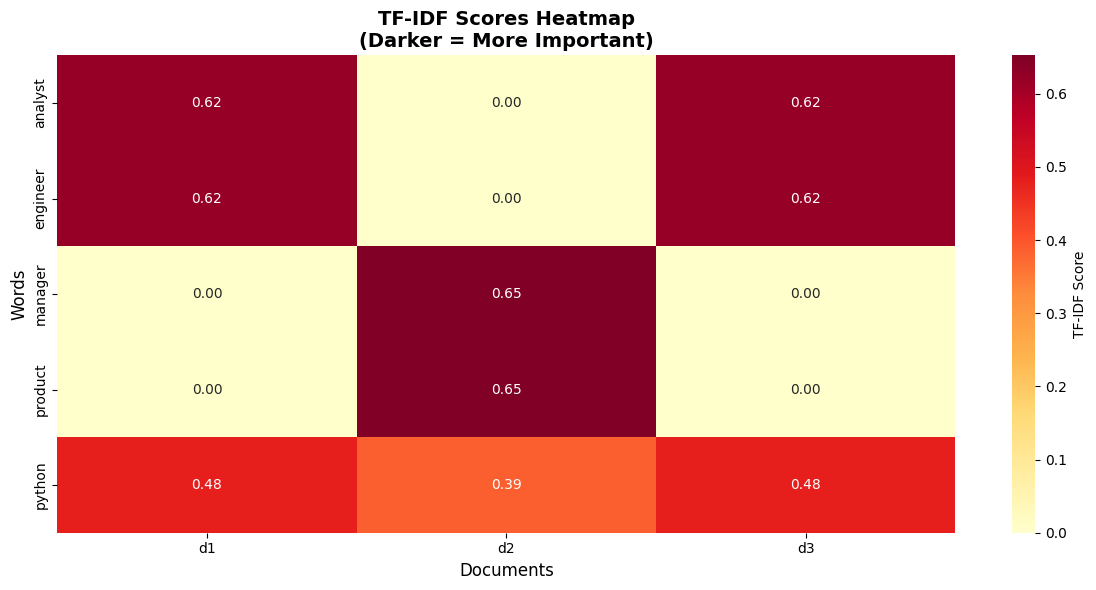


 Each review has its own 'signature' words that distinguish it!


In [ ]:
# Create heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(tfidf_df.T, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'TF-IDF Score'})
plt.title('TF-IDF Scores Heatmap\n(Darker = More Important)', fontsize=14, fontweight='bold')
plt.xlabel('Documents', fontsize=12)
plt.ylabel('Words', fontsize=12)
plt.tight_layout()
plt.show()

print("\n Each review has its own 'signature' words that distinguish it!")

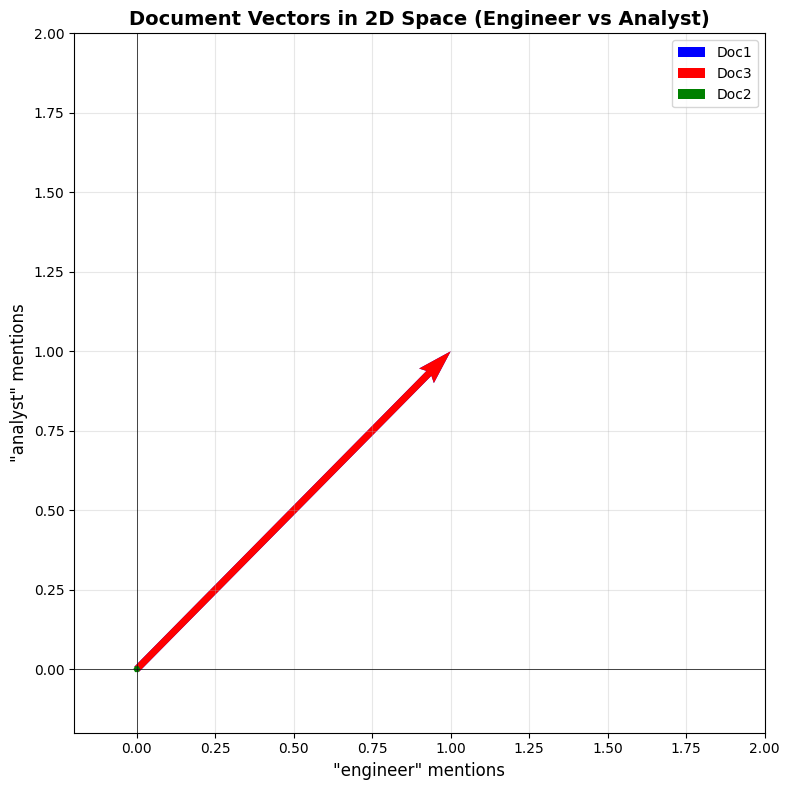


Cosine Similarities:
 doc1 vs doc2: 0.577
 doc1 vs doc3: 0.816
 doc2 vs doc3: 0.000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Document vectors: [engineer, analysts, product, manager]
doc1 = np.array([1, 1, 1, 0])  # python engineer analyst
doc2 = np.array([0, 0, 1, 0])  # product manager python
doc3 = np.array([1, 1, 0, 0])  # python analyst engineer

# --- 2D Visualization (engineer vs analyst) ---
plt.figure(figsize=(8, 8))

# TRUE vectors, no jitter
plt.quiver(0, 0, doc1[0], doc1[1],
           angles='xy', scale_units='xy', scale=1,
           color='blue', width=0.01, label='Doc1')

plt.quiver(0, 0, doc3[0], doc3[1],
           angles='xy', scale_units='xy', scale=1,
           color='red', width=0.01, label='Doc3')

plt.quiver(0, 0, doc2[0], doc2[1],
           angles='xy', scale_units='xy', scale=1,
           color='green', width=0.01, label='Doc2')

plt.xlim(-0.2, 2)
plt.ylim(-0.2, 2)
plt.xlabel('"engineer" mentions', fontsize=12)
plt.ylabel('"analyst" mentions', fontsize=12)
plt.title('Document Vectors in 2D Space (Engineer vs Analyst)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()

# Calculate similarities
sim_1_2 = cosine_similarity([doc1], [doc2])[0][0]
sim_1_3 = cosine_similarity([doc1], [doc3])[0][0]
sim_2_3 = cosine_similarity([doc2], [doc3])[0][0]

print("\nCosine Similarities:")
print(f" doc1 vs doc2: {sim_1_2:.3f}")
print(f" doc1 vs doc3: {sim_1_3:.3f}")
print(f" doc2 vs doc3: {sim_2_3:.3f}")

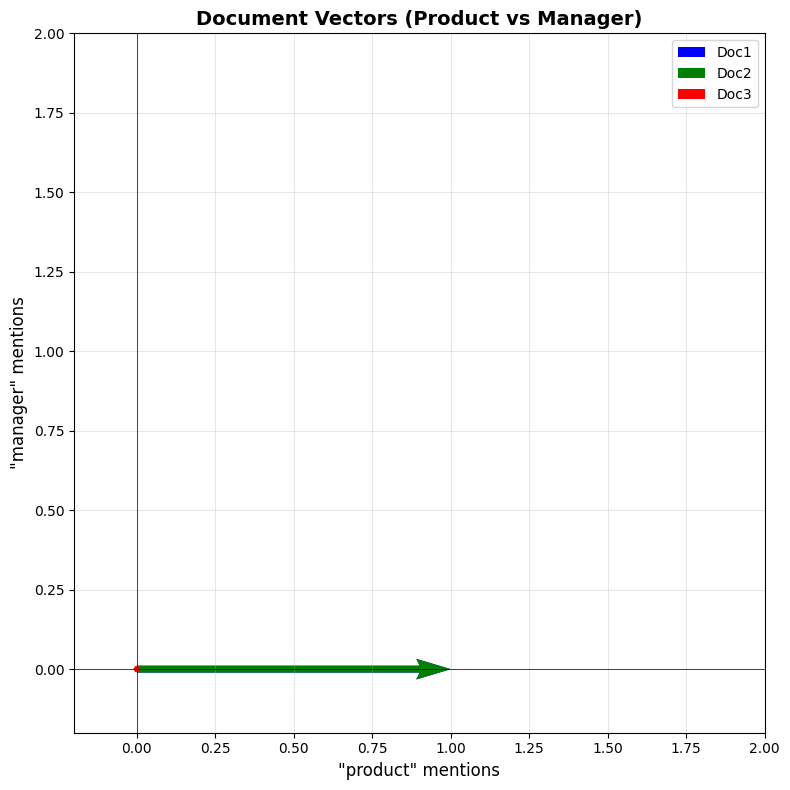


Cosine Similarities:
 doc1 vs doc2: 0.577
 doc1 vs doc3: 0.816
 doc2 vs doc3: 0.000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Vocabulary: [engineer, analysts, product, manager]
doc1 = np.array([1, 1, 1, 0])
doc2 = np.array([0, 0, 1, 0])
doc3 = np.array([1, 1, 0, 0])

plt.figure(figsize=(8, 8))

# Plot true vectors (no shifting)
plt.quiver(0, 0, doc1[2], doc1[3],
           angles='xy', scale_units='xy', scale=1,
           color='blue', width=0.01, label='Doc1')

plt.quiver(0, 0, doc2[2], doc2[3],
           angles='xy', scale_units='xy', scale=1,
           color='green', width=0.01, label='Doc2')

plt.quiver(0, 0, doc3[2], doc3[3],
           angles='xy', scale_units='xy', scale=1,
           color='red', width=0.01, label='Doc3')

plt.xlim(-0.2, 2)
plt.ylim(-0.2, 2)
plt.xlabel('"product" mentions', fontsize=12)
plt.ylabel('"manager" mentions', fontsize=12)
plt.title('Document Vectors (Product vs Manager)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()

# --- Cosine Similarities ---
sim_1_2 = cosine_similarity([doc1], [doc2])[0][0]
sim_1_3 = cosine_similarity([doc1], [doc3])[0][0]
sim_2_3 = cosine_similarity([doc2], [doc3])[0][0]

print("\nCosine Similarities:")
print(f" doc1 vs doc2: {sim_1_2:.3f}")
print(f" doc1 vs doc3: {sim_1_3:.3f}")
print(f" doc2 vs doc3: {sim_2_3:.3f}")

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

docs = [
    "python engineer analyst",
    "product manager python",
    "python analyst engineer"
]

query = ["python manager"]

#TF_IDF vectorization
vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform(docs + query)

# Split into docs and query
doc_vectors = tfidf[:-1]
query_vector = tfidf[-1]

# Compute cosine similarities
sims = cosine_similarity(query_vector, doc_vectors)[0]

print("Similarity to D1:", sims[0])
print("Similarity to D2:", sims[1])
print("Similarity to D3:", sims[2])

# Determine closest document
closest_doc = sims.argmax() + 1
print(f"\nThe Query 'python manager' is Closest to Document {closest_doc}.")

Similarity to D1: 0.2339653183395522
Similarity to D2: 0.6870168423040602
Similarity to D3: 0.2339653183395522

The Query 'python manager' is Closest to Document 2.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate cosine similarity matrix using TF-IDF vectors
similarity_matrix = cosine_similarity(tfidf_matrix)

# Convert to DataFrame for better visualization
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=tfidf_df.index,
    columns=tfidf_df.index
)

print(" Cosine Similarity Matrix:")
print(similarity_df.round(3))
print("\n The diagonal is always 1.0 (each document is identical to itself)")

 Cosine Similarity Matrix:
       d1     d2     d3
d1  1.000  0.185  1.000
d2  0.185  1.000  0.185
d3  1.000  0.185  1.000

 The diagonal is always 1.0 (each document is identical to itself)


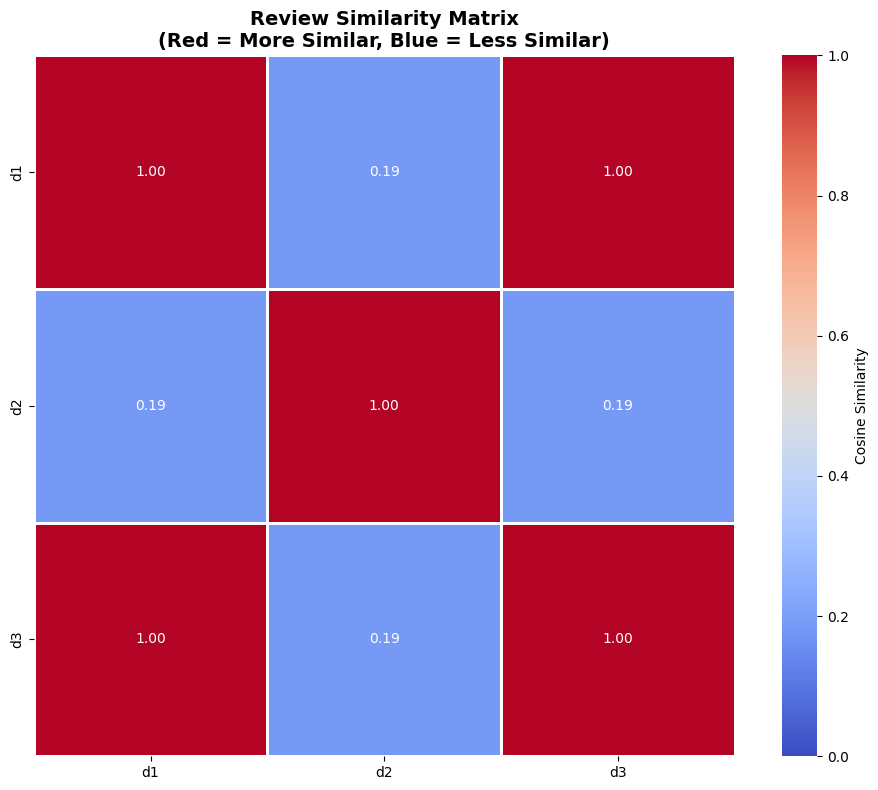

In [ ]:
# Visualize similarity matrix
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_df, annot=True, fmt='.2f', cmap='coolwarm', center=0.5,
            vmin=0, vmax=1, square=True, linewidths=1,
            cbar_kws={'label': 'Cosine Similarity'})
plt.title('Review Similarity Matrix\n(Red = More Similar, Blue = Less Similar)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("Finding Most Similar Document Pairs:\n")

# Get upper triangle of similarity matrix (to avoid duplicates)
for i in range(len(documents)):
    for j in range(i+1, len(documents)):
        similarity = similarity_matrix[i][j]
        if similarity > 0.1:  # Only show pairs with some similarity
            print(f"{documents_names[i]} ↔ {documents_names[j]}: {similarity:.3f}")
            print(f"  {documents_names[i]}: {documents[i][:50]}...")
            print(f"  {documents_names[j]}: {documents[j][:50]}...")
            print()

# Find the most similar pair
max_sim = 0
max_pair = (0, 0)
for i in range(len(documents)):
    for j in range(i+1, len(documents)):
        if similarity_matrix[i][j] > max_sim:
            max_sim = similarity_matrix[i][j]
            max_pair = (i, j)

print(f"\n Most Similar Pair: {documents_names[max_pair[0]]} and {documents_names[max_pair[1]]}")
print(f"Similarity Score: {max_sim:.3f}")

Finding Most Similar Document Pairs:

p ↔ y: 0.185
  p: python engineer analyst...
  y: product manager python...

p ↔ t: 1.000
  p: python engineer analyst...
  t: python analyst engineer...

y ↔ t: 0.185
  y: product manager python...
  t: python analyst engineer...


 Most Similar Pair: p and t
Similarity Score: 1.000


Question 2a

In [ ]:
import pandas as pd

corpus=[
  "<s> I like strawberries </s>",
  "<s> You like all strawberries </s>",
  "<s> I hate sour fruits </s>",
  "<s> You like all sweet fruits </s>",
  "<s> I like chocolate covered strawberries </s>"
]

#Table of raw sentences
df_corpus=pd.DataFrame(corpus, columns=["sentences"])
print(df_corpus)

#Split into tokens (whitespace only)
print("\nTokenized sentence list:")
sentences=[s.split() for s in corpus]
print(sentences)

#Table of token lists
df_tokens = pd.DataFrame({
    "Sentence #": range(1, len(corpus)+1),
    "Tokens": sentences
})

print("\nToken Table:")
print(df_tokens)

                                        sentences
0                    <s> I like strawberries </s>
1              <s> You like all strawberries </s>
2                     <s> I hate sour fruits </s>
3              <s> You like all sweet fruits </s>
4  <s> I like chocolate covered strawberries </s>

Tokenized sentence list:
[['<s>', 'I', 'like', 'strawberries', '</s>'], ['<s>', 'You', 'like', 'all', 'strawberries', '</s>'], ['<s>', 'I', 'hate', 'sour', 'fruits', '</s>'], ['<s>', 'You', 'like', 'all', 'sweet', 'fruits', '</s>'], ['<s>', 'I', 'like', 'chocolate', 'covered', 'strawberries', '</s>']]

Token Table:
   Sentence #                                             Tokens
0           1                 [<s>, I, like, strawberries, </s>]
1           2          [<s>, You, like, all, strawberries, </s>]
2           3                 [<s>, I, hate, sour, fruits, </s>]
3           4         [<s>, You, like, all, sweet, fruits, </s>]
4           5  [<s>, I, like, chocolate, covered, strawbe

In [ ]:
# Build bigram rows
bigram_rows = []

for idx, tokens in enumerate(sentences, start=1):
    for i in range(len(tokens)-1):
        bigram_rows.append({
            "Sentence #": idx,
            "w1": tokens[i],
            "w2": tokens[i+1]
        })

# Convert to DataFrame
df_bigrams = pd.DataFrame(bigram_rows)
print("\nBigram Table:")
print(df_bigrams)


Bigram Table:
    Sentence #            w1            w2
0            1           <s>             I
1            1             I          like
2            1          like  strawberries
3            1  strawberries          </s>
4            2           <s>           You
5            2           You          like
6            2          like           all
7            2           all  strawberries
8            2  strawberries          </s>
9            3           <s>             I
10           3             I          hate
11           3          hate          sour
12           3          sour        fruits
13           3        fruits          </s>
14           4           <s>           You
15           4           You          like
16           4          like           all
17           4           all         sweet
18           4         sweet        fruits
19           4        fruits          </s>
20           5           <s>             I
21           5             I          l

In [ ]:
# Count occurrences of each (w1, w2)
df_bigram_counts = (
    df_bigrams
    .groupby(["w1", "w2"])
    .size()
    .reset_index(name="count")
)

print("\nBigram Counts:")
print(df_bigram_counts)



Bigram Counts:
              w1            w2  count
0            <s>             I      3
1            <s>           You      2
2              I          hate      1
3              I          like      2
4            You          like      2
5            all  strawberries      1
6            all         sweet      1
7      chocolate       covered      1
8        covered  strawberries      1
9         fruits          </s>      2
10          hate          sour      1
11          like           all      2
12          like     chocolate      1
13          like  strawberries      1
14          sour        fruits      1
15  strawberries          </s>      3
16         sweet        fruits      1


In [ ]:
# Count how many times each w1 appears as a first word
df_w1_counts = (
    df_bigrams
    .groupby("w1")
    .size()
    .reset_index(name="w1_total")
)

print("\nw1 Counts:")
print(df_w1_counts)


w1 Counts:
              w1  w1_total
0            <s>         5
1              I         3
2            You         2
3            all         2
4      chocolate         1
5        covered         1
6         fruits         2
7           hate         1
8           like         4
9           sour         1
10  strawberries         3
11         sweet         1


In [ ]:
# Merge counts and compute probabilities
df_bigram_prob = df_bigram_counts.merge(df_w1_counts, on="w1")
df_bigram_prob["P(w2|w1)"] = df_bigram_prob["count"] / df_bigram_prob["w1_total"]

print("\nBigram Probability Table:")
print(df_bigram_prob)


Bigram Probability Table:
              w1            w2  count  w1_total  P(w2|w1)
0            <s>             I      3         5  0.600000
1            <s>           You      2         5  0.400000
2              I          hate      1         3  0.333333
3              I          like      2         3  0.666667
4            You          like      2         2  1.000000
5            all  strawberries      1         2  0.500000
6            all         sweet      1         2  0.500000
7      chocolate       covered      1         1  1.000000
8        covered  strawberries      1         1  1.000000
9         fruits          </s>      2         2  1.000000
10          hate          sour      1         1  1.000000
11          like           all      2         4  0.500000
12          like     chocolate      1         4  0.250000
13          like  strawberries      1         4  0.250000
14          sour        fruits      1         1  1.000000
15  strawberries          </s>      3        

Question 2b

In [ ]:

# Convert probability table to dictionary for fast lookup
prob_dict = {
    (row["w1"], row["w2"]): row["P(w2|w1)"]
    for _, row in df_bigram_prob.iterrows()
}

def sentence_probability(sentence):
    tokens = sentence.split()
    prob = 1
    for i in range(len(tokens)-1):
        pair = (tokens[i], tokens[i+1])
        if pair not in prob_dict:
            return 0
        prob *= prob_dict[pair]
    return prob

print("P(<s> You like all strawberries </s>) =", sentence_probability("<s> You like all strawberries </s>"))

print("P(<s> You hate sour fruits </s>) =", sentence_probability("<s> You hate sour fruits </s>"))

P(<s> You like all strawberries </s>) = 0.1
P(<s> You hate sour fruits </s>) = 0


In [ ]:
# Compute sentence probabilities
s1 = "<s> You like all strawberries </s>"
s2 = "<s> You hate sour fruits </s>"

print("\nSentence Probabilities:")
print("P(s1) =", sentence_probability(s1))
print("P(s2) =", sentence_probability(s2))


Sentence Probabilities:
P(s1) = 0.1
P(s2) = 0


AI Resources: Microsoft Copilot and Gemini

